--- 1. Marketing Data Overview ---
Dataset Size: (11162, 17)

--- 2. Exploratory Business Insights ---


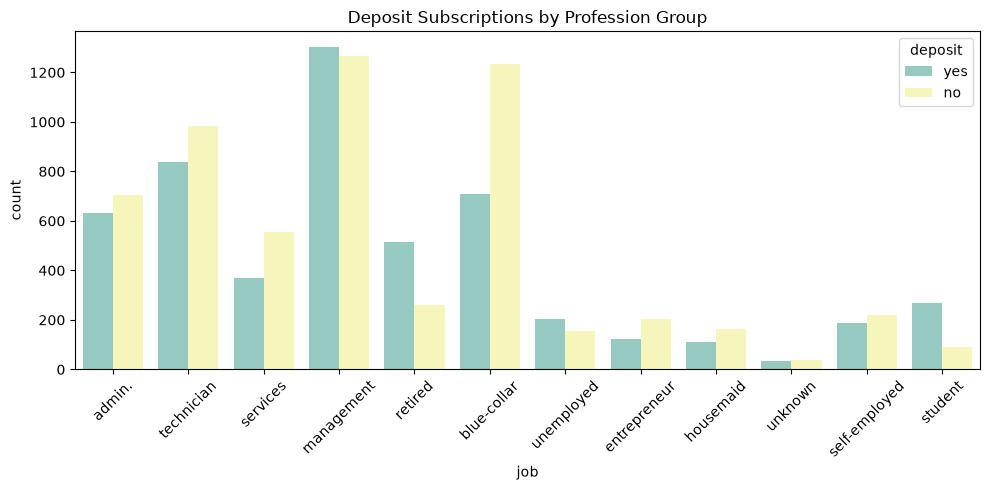


--- 3. Feature Preparation ---

--- 4. Classification Execution ---

--- 5. Evaluation & Conversion Performance ---
Campaign Model Accuracy: 0.8056

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1175
           1       0.79      0.81      0.80      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233


--- 6. Key Strategic Business Takeaway ---
Features detailing structural duration spent on the phone correlate heavily with conversion trends.


In [1]:
# ==========================================
# TASK 5: BANK DEPOSIT MARKETING PREDICTION
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

print("--- 1. Marketing Data Overview ---")
df_bank = pd.read_csv("bank.csv")
print(f"Dataset Size: {df_bank.shape}")

print("\n--- 2. Exploratory Business Insights ---")
plt.figure(figsize=(10, 5))
sns.countplot(data=df_bank, x='job', hue='deposit', palette='Set3')
plt.xticks(rotation=45)
plt.title("Deposit Subscriptions by Profession Group")
plt.tight_layout()
plt.show()

print("\n--- 3. Feature Preparation ---")
# Convert Target variable 'deposit' (yes/no) to 1/0
df_bank['deposit'] = df_bank['deposit'].map({'yes': 1, 'no': 0})

# Encode remaining categorical variables
X = df_bank.drop(columns=['deposit'])
y = df_bank['deposit']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- 4. Classification Execution ---")
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

print("\n--- 5. Evaluation & Conversion Performance ---")
print(f"Campaign Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\n--- 6. Key Strategic Business Takeaway ---")
print("Features detailing structural duration spent on the phone correlate heavily with conversion trends.")